#This notebook explores the performance of the Hybrid CNN-LSTM, CNN-LSTM-RESIDUAL and CNN-CONFORMER models on a classification task using EEG data.

In [ ]:
!pip install keras==3.13.2

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout, Conv2D, LSTM, BatchNormalization, MaxPooling2D, Reshape
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
keras.utils.set_random_seed(SEED)


In [ ]:
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/Colab Notebooks/cvae_project/"
    os.chdir(base_path)
else:
    base_path = "."

Mounted at /content/drive


In [10]:
# Importing custom models and preprocessing
from src.preprocessing import data_prep as dp

from src.models import cnn_lstm, cnn_lstm_res, cnn_conformer

# # In case of reloading...
# import importlib
# importlib.reload(cnn_lstm)
# importlib.reload(cnn_lstm_res)
# importlib.reload(cnn_conformer)

## (i) Load and pre-processing the dataset; prepare the training, validation, and test data.



In [ ]:
# ----------------------------
# Loading Data
# ----------------------------
X_test = np.load(base_path + "data/X_test.npy")
y_test = np.load(base_path + "data/y_test.npy")
person_train_valid = np.load(base_path +"data/person_train_valid.npy")
X_train_valid = np.load(base_path +"data/X_train_valid.npy")
y_train_valid = np.load(base_path +"data/y_train_valid.npy")
person_test = np.load(base_path +"data/person_test.npy")

# ----------------------------
#  Data Pre-Processing - dp.prepare_dataset (mode = 'cnn') for CNN_LSTM, CNN_LSTM_RESIDUAL
# ----------------------------
y_train_valid -= 769
y_test -= 769

x_train, x_valid, x_test, y_train, y_valid, y_test = dp.prepare_dataset(
    X_train_valid, y_train_valid, X_test, y_test, mode='cnn'
)

Shape of X after trimming: (1740, 22, 500)
Shape of X after maxpooling: (1740, 22, 250)
Shape of X after averaging+noise and concatenating: (3480, 22, 250)
Shape of X after subsampling and concatenating: (6960, 22, 250)
Shape of X after trimming: (375, 22, 500)
Shape of X after maxpooling: (375, 22, 250)
Shape of X after averaging+noise and concatenating: (750, 22, 250)
Shape of X after subsampling and concatenating: (1500, 22, 250)
Shape of X after trimming: (443, 22, 500)
Shape of X after maxpooling: (443, 22, 250)
Shape of X after averaging+noise and concatenating: (886, 22, 250)
Shape of X after subsampling and concatenating: (1772, 22, 250)
Shape of testing set: (1772, 22, 250)
Shape of testing labels: (1772,)
Shape of training set: (6960, 22, 250)
Shape of validation set: (1500, 22, 250)
Shape of training labels: (6960,)
Shape of validation labels: (1500,)
Shape of training labels after categorical conversion: (6960, 4)
Shape of validation labels after categorical conversion: (15

## (ii) CNN-LSTM: Defining the model architecture, 50 epoch run, visualization, and performance.


In [ ]:
model = cnn_lstm.CNN_LSTM()
model.build()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


this is the new cnn lstm model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 250, 1, 25)     │         5,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 84, 1, 25)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 84, 1, 25)      │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84, 1, 25)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 84, 1, 50)      │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 1, 50)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 1, 50)      │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 1, 50)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 1, 100)     │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 1, 100)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 1, 100)     │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 1, 100)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 1, 200)     │       200,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 1, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 1, 200)      │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 1, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        80,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,499 (1.34 MB)

 Trainable params: 349,749 (1.33 MB)

 Non-trainable params: 750 (2.93 KB)

In [ ]:
# ----------------------------
# CNN LSTM
# ----------------------------
model = cnn_lstm.CNN_LSTM(input_shape=(250, 1, 22))
learning_rate = 1e-3
model.compile(loss='categorical_crossentropy',
                  optimizer=keras.optimizers.Adam(learning_rate),
                  metrics=['accuracy'])
#model.build()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
cnn_lstm_results = model.fit(x_train,
             y_train,
             batch_size=64,
             epochs=50,
             validation_data=(x_valid, y_valid), verbose=True)


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.2652 - loss: 1.3828 - val_accuracy: 0.3407 - val_loss: 1.3587
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.3066 - loss: 1.3566 - val_accuracy: 0.3247 - val_loss: 1.3300
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.3481 - loss: 1.3283 - val_accuracy: 0.4053 - val_loss: 1.3040
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.4122 - loss: 1.2777 - val_accuracy: 0.4267 - val_loss: 1.2805
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 190ms/step - accuracy: 0.4302 - loss: 1.2482 - val_accuracy: 0.3767 - val_loss: 1.2910
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 190ms/step - accuracy: 0.4555 - loss: 1.2069 - val_accuracy: 0.4220 - val_loss: 1.2755
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 202ms/step - accuracy: 0.4557 - loss: 1.1956 - val_accuracy: 0.4173 - val_loss: 1.2643
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - accuracy: 0.4612 - loss: 1

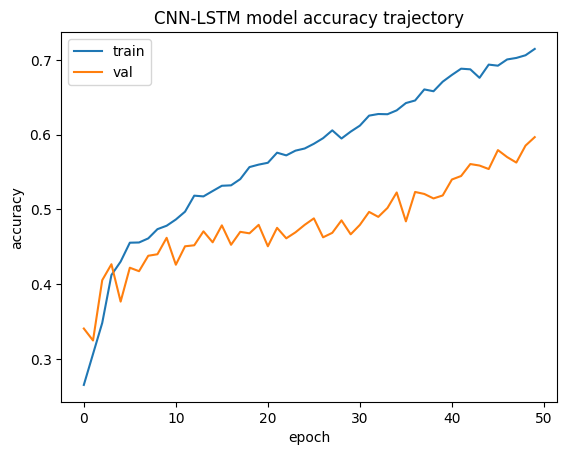

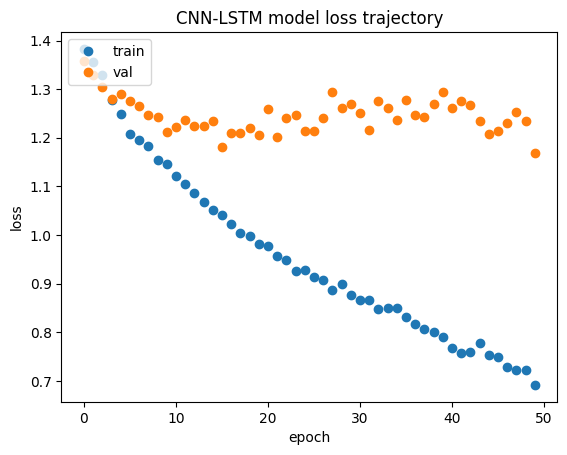

In [ ]:
# Plotting accuracy trajectory
plt.plot(cnn_lstm_results.history['accuracy'])
plt.plot(cnn_lstm_results.history['val_accuracy'])
plt.title('CNN-LSTM model accuracy trajectory')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Plotting loss trajectory
plt.plot(cnn_lstm_results.history['loss'],'o')
plt.plot(cnn_lstm_results.history['val_loss'],'o')
plt.title('CNN-LSTM model loss trajectory')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:

cnn_lstm_score = model.evaluate(x_test, y_test, verbose=0)
print('Test accuracy of the hybrid CNN-LSTM model:',cnn_lstm_score[1])

Test accuracy of the hybrid CNN-LSTM model: 0.5931151509284973


## (iii) CNN-LSTM-RESIDUAL: Defining the model architecture, 50 epoch run, visualization, and performance.

In [12]:
model = cnn_lstm_res.CNN_LSTM_RES()
dummy = np.zeros((1, 250, 1, 22))  # batch of 1, matching your input shape
model(dummy)                        # triggers call(), builds all branches
model.summary(expand_nested=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_lstm_res_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 84, 1, 25)      │         5,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_11 (Conv2D)         │ (None, 250, 1, 25)     │         5,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_11           │ (None, 84, 1, 25)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_8      │ (None, 84, 1, 25)      │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_8 (Dropout)        │ (None, 84, 1, 25)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (1, 28, 1, 50)         │        12,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_12 (Conv2D)         │ (1, 84, 1, 50)         │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_12           │ (1, 28, 1, 50)         │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_9      │ (1, 28, 1, 50)         │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_9 (Dropout)        │ (1, 28, 1, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (1, 28, 1, 50)         │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_13 (Conv2D)         │ (1, 84, 1, 50)         │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_13           │ (1, 28, 1, 50)         │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (1, 10, 1, 100)        │        50,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_14 (Conv2D)         │ (1, 28, 1, 100)        │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_14           │ (1, 10, 1, 100)        │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_10     │ (1, 10, 1, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_10 (Dropout)       │ (1, 10, 1, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (1, 10, 1, 100)        │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_15 (Conv2D)         │ (1, 28, 1, 100)        │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_15           │ (1, 10, 1, 100)        │             0 │
│ (MaxPooling2D)                  │                        │             

 Total params: 377,099 (1.44 MB)

 Trainable params: 376,349 (1.44 MB)

 Non-trainable params: 750 (2.93 KB)

In [16]:
# ----------------------------
#  CNN LSTM RESIDUAL
# ----------------------------
model = cnn_lstm_res.CNN_LSTM_RES(input_shape=(250, 1, 22))
learning_rate = 1e-3
model.compile(loss='categorical_crossentropy',
                  optimizer=keras.optimizers.Adam(learning_rate),
                  metrics=['accuracy'])
model.build(input_shape=(250, 1, 22))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cnn_lstm_res_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [17]:
cnn_lstm_residual_results = model.fit(x_train,
             y_train,
             batch_size=64,
             epochs=50,
             validation_data=(x_valid, y_valid), verbose=True)

model.evaluate(x_test, y_test, verbose=0)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 226ms/step - accuracy: 0.2644 - loss: 1.3825 - val_accuracy: 0.3107 - val_loss: 1.3700
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - accuracy: 0.3106 - loss: 1.3683 - val_accuracy: 0.2927 - val_loss: 1.3967
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.3534 - loss: 1.3425 - val_accuracy: 0.2807 - val_loss: 1.4200
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.3899 - loss: 1.2985 - val_accuracy: 0.3207 - val_loss: 1.3637
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.4164 - loss: 1.2628 - val_accuracy: 0.3840 - val_loss: 1.3336
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - accuracy: 0.4546 - loss: 1.2178 - val_accuracy: 0.4047 - val_loss: 1.3345
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.4670 - loss: 1.1833 - val_accuracy: 0.3480 - val_loss: 1.3870
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.4829 - loss: 1

[1.6748703718185425, 0.5840857625007629]

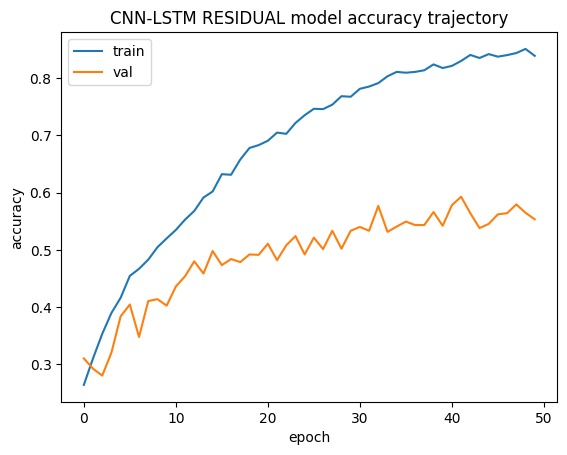

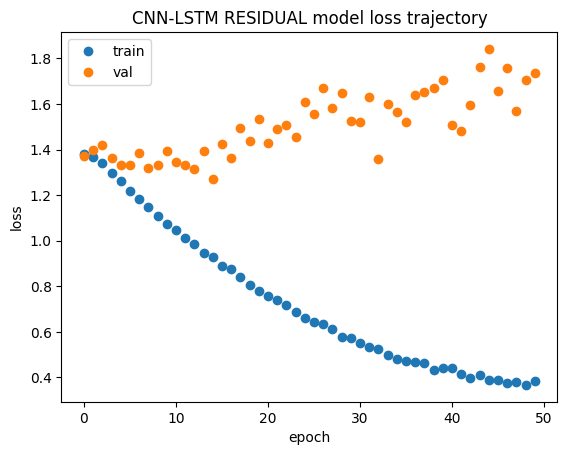

In [18]:
# Plotting accuracy trajectory
plt.plot(cnn_lstm_residual_results.history['accuracy'])
plt.plot(cnn_lstm_residual_results.history['val_accuracy'])
plt.title('CNN-LSTM RESIDUAL model accuracy trajectory')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Plotting loss trajectory
plt.plot(cnn_lstm_residual_results.history['loss'],'o')
plt.plot(cnn_lstm_residual_results.history['val_loss'],'o')
plt.title('CNN-LSTM RESIDUAL model loss trajectory')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## (iv) CNN-CONFORMER: Defining the model architecture, 50 epoch run, visualization, and performance.

In [20]:
model = cnn_conformer.CNN_CONFORMER()
dummy = np.zeros((1, 250, 1, 22))
model(dummy)
model.summary(expand_nested=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'conformer_conv_module_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'conformer_conv_module_3', however the layer does not have a `build()` method implemented and it looks like

Model: "cnn_conformer_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_39 (Sequential)      │ (None, 84, 1, 25)      │         5,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_39 (Conv2D)         │ (None, 250, 1, 25)     │         5,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_39           │ (None, 84, 1, 25)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_26     │ (None, 84, 1, 25)      │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_32 (Dropout)       │ (None, 84, 1, 25)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_40 (Sequential)      │ (1, 28, 1, 50)         │        12,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_40 (Conv2D)         │ (1, 84, 1, 50)         │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_40           │ (1, 28, 1, 50)         │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_27     │ (1, 28, 1, 50)         │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_33 (Dropout)       │ (1, 28, 1, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_41 (Sequential)      │ (1, 28, 1, 50)         │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_41 (Conv2D)         │ (1, 84, 1, 50)         │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_41           │ (1, 28, 1, 50)         │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_42 (Sequential)      │ (1, 10, 1, 100)        │        50,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_42 (Conv2D)         │ (1, 28, 1, 100)        │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_42           │ (1, 10, 1, 100)        │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_28     │ (1, 10, 1, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_34 (Dropout)       │ (1, 10, 1, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_43 (Sequential)      │ (1, 10, 1, 100)        │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_43 (Conv2D)         │ (1, 28, 1, 100)        │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_43           │ (1, 10, 1, 100)        │             0 │
│ (MaxPooling2D)                  │                        │             

 Total params: 829,343 (3.16 MB)

 Trainable params: 828,081 (3.16 MB)

 Non-trainable params: 1,262 (4.93 KB)

In [21]:
# ----------------------------
#  CNN Conformer
# ----------------------------

model = cnn_conformer.CNN_CONFORMER(input_shape=(250, 1, 22))
learning_rate = 1e-3
model.compile(loss='categorical_crossentropy',
                  optimizer=keras.optimizers.Adam(learning_rate),
                  metrics=['accuracy'])
model.build(input_shape=(250, 1, 22))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cnn_conformer_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [22]:
cnn_conf_results = model.fit(x_train,
             y_train,
             batch_size=64,
             epochs=50,
             validation_data=(x_valid, y_valid), verbose=True)

model.evaluate(x_test, y_test, verbose=0)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'conformer_conv_module_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'conformer_conv_module_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 413ms/step - accuracy: 0.3412 - loss: 1.3802 - val_accuracy: 0.3380 - val_loss: 1.3828
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 381ms/step - accuracy: 0.4987 - loss: 1.1503 - val_accuracy: 0.4267 - val_loss: 1.2634
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 43s 398ms/step - accuracy: 0.5783 - loss: 1.0139 - val_accuracy: 0.4347 - val_loss: 1.2676
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 372ms/step - accuracy: 0.6270 - loss: 0.9209 - val_accuracy: 0.4887 - val_loss: 1.2469
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.6761 - loss: 0.8087 - val_accuracy: 0.5007 - val_loss: 1.2441
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 382ms/step - accuracy: 0.7299 - loss: 0.6947 - val_accuracy: 0.5133 - val_loss: 1.4126
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 386ms/step - accuracy: 0.7743 - loss: 0.5940 - val_accuracy: 0.5033 - val_loss: 1.5472
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 377ms/step - accuracy: 0.8039 - loss: 0.5132 - val

[2.4536752700805664, 0.5677201151847839]

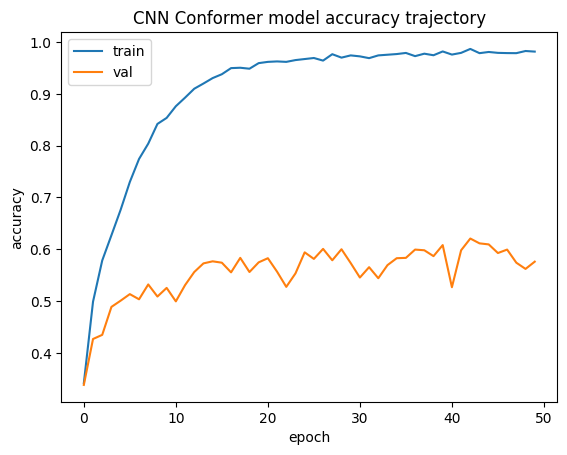

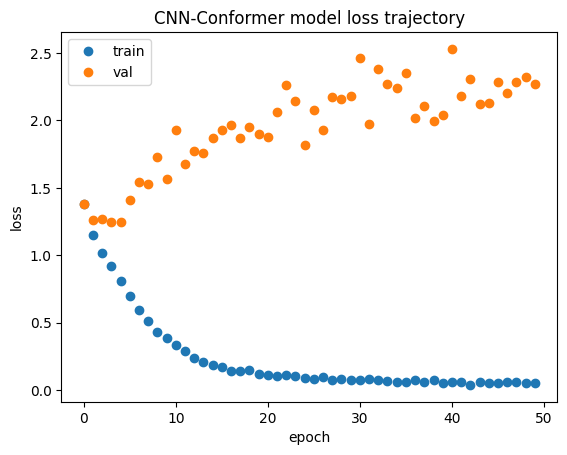

In [27]:
# Plotting accuracy trajectory
plt.plot(cnn_conf_results.history['accuracy'])
plt.plot(cnn_conf_results.history['val_accuracy'])
plt.title('CNN Conformer model accuracy trajectory')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Plotting loss trajectory
plt.plot(cnn_conf_results.history['loss'],'o')
plt.plot(cnn_conf_results.history['val_loss'],'o')
plt.title('CNN-Conformer model loss trajectory')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Results & Discussion

## Test Results Summary

| Model             | Accuracy |
|-------------------|----------|
| CNN-LSTM          | ~62.2%   |
| CNN-LSTM-Residual | 58.41%   |
| CNN-Conformer     | 56.77%   |

*CNN-LSTM accuracy is reported as a mean across two runs (65%, 59.31%)
reflecting runtime variability observed in Google Colab.*

## Discussion

In individual runs, CNN-LSTM achieved the highest mean test accuracy at ~62.2%, followed by CNN-LSTM-Residual at 58.41% and CNN-Conformer at 56.77%. The three models perform within a range of approximately 5%, suggesting the CNN feature extraction frontend is the dominant contributor to performance regardless of the temporal modelling strategy used in the tail.

The CNN-LSTM-Residual performing comparably to the plain CNN-LSTM is notable.  The residual connections do not appear to be providing a clear benefit in this setting. This may warrant further investigation into the learning rate, dropout rates.
The CNN-Conformer ranking last in individual runs is surprising given that attention-based architectures have shown strong results on EEG motor imagery tasks in the literature. With only 50 epochs and a sequence length of 4 tokens after the CNN frontend, the Conformer may not have enough temporal context to fully leverage self-attention.

 A standalone baseline result is documented in `00_baseline_cnn_lstm.ipynb`.

## Future Work

All three models show signs of overfitting, suggesting the following adjustments:

- **CNN-LSTM**: Increase training budget beyond 50 epochs; val loss plateaus
  rather than diverging, suggesting the model has room to improve with longer training.
- **CNN-LSTM-Residual**: Increase dropout and add L2 regularization to conv layers; val loss diverges from epoch 10 indicating the model has too much capacity relative to the dataset.
- **CNN-Conformer**: Reduce model capacity (d_model 128 -> 64, 2 blocks -> 1) before tuning regularization.

